# Explore variance distribution

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import tqdm
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

In [2]:
# Import isoform_tools
exec(open("/home/matei/Neuroblastoma-project-course/isoform_tools.py").read())

In [3]:
#DATA_PATH="C:/Users/Felix/Desktop/vs_code/translational_control/data"

In [4]:
#adata=sc.read("/adata_thresholded.h5ad")
adata = sc.read("/home/matei/data/adata_neuroblastoma_assigned.h5ad")

In [5]:
adata=adata[~adata.obs.leiden.isin(["7","10","11","6","11","8"])]

In [10]:
print(f"number of genes: {len(adata.var["gene"].unique())}")
print(f"number of transcripts: {len(adata.var["transcript"].unique())}")

number of genes: 68918
number of transcripts: 331361


In [6]:

# Filter on isoform count.
# Read keep isoforms
with open("C:/Users/Felix/Desktop/vs_code/translational_control/information_content/keep_isoforms.txt", "r") as f:
    list_ = f.readlines()


keep=[]
for x in list_:
    keep.append(x[:-1])

# Need to redo keep because it was calculated on adata_preprocessed
keep_new = []
for x in tqdm.tqdm(keep):
    if x in adata.var_names.tolist():
        keep_new.append(x)
adata = adata[:,keep_new]

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Felix/Desktop/vs_code/translational_control/information_content/keep_isoforms.txt'

### Filter based on total isoform expression

In [16]:
# Calculate expr per isoform

expr = np.asarray(adata.X.sum(axis=0)).ravel()

df = pd.DataFrame({
    "transcript": adata.var["transcript"].values,
    "expr": expr
})

sum_iex = df.groupby("transcript")["expr"].sum().to_dict()

In [12]:
len(df.transcript[df["expr"]>30].tolist())

12562

In [13]:
iso_to_keep = df.transcript[df["expr"]>30].tolist()

In [14]:
adata = adata[:, adata.var["transcript"].isin(iso_to_keep)]

In [15]:
print(f"number of genes: {len(adata.var["gene"].unique())}")
print(f"number of transcripts: {len(adata.var["transcript"].unique())}")

number of genes: 8796
number of transcripts: 12562


### Filter based on isoform number (<1)

In [17]:
gene_list = adata.var["gene"].unique().tolist()

In [18]:
multi_iso = []

for gene in tqdm.tqdm(gene_list):
    n_iso = len(adata.var[adata.var["gene"]==gene])
    #print(f"n_iso:{n_iso}")
    if n_iso > 1:
        multi_iso.append(gene)

len(multi_iso)

100%|██████████| 8796/8796 [00:06<00:00, 1313.29it/s]


2252

In [19]:
adata = adata[:, adata.var["gene"].isin(multi_iso)]

In [20]:
print(f"number of genes: {len(adata.var["gene"].unique())}")
print(f"number of transcripts: {len(adata.var["transcript"].unique())}")

number of genes: 2252
number of transcripts: 6018


### Filter based on total gene expression

In [30]:
gene_list = adata.var["gene"].unique().tolist() 
sum_gex={} 
for gene in tqdm.tqdm(gene_list): 
    transcripts = adata.var[adata.var["gene"] == gene].index 
    sum_gex[gene] = adata[:, transcripts].X.sum().item()

100%|██████████| 661/661 [01:53<00:00,  5.80it/s]


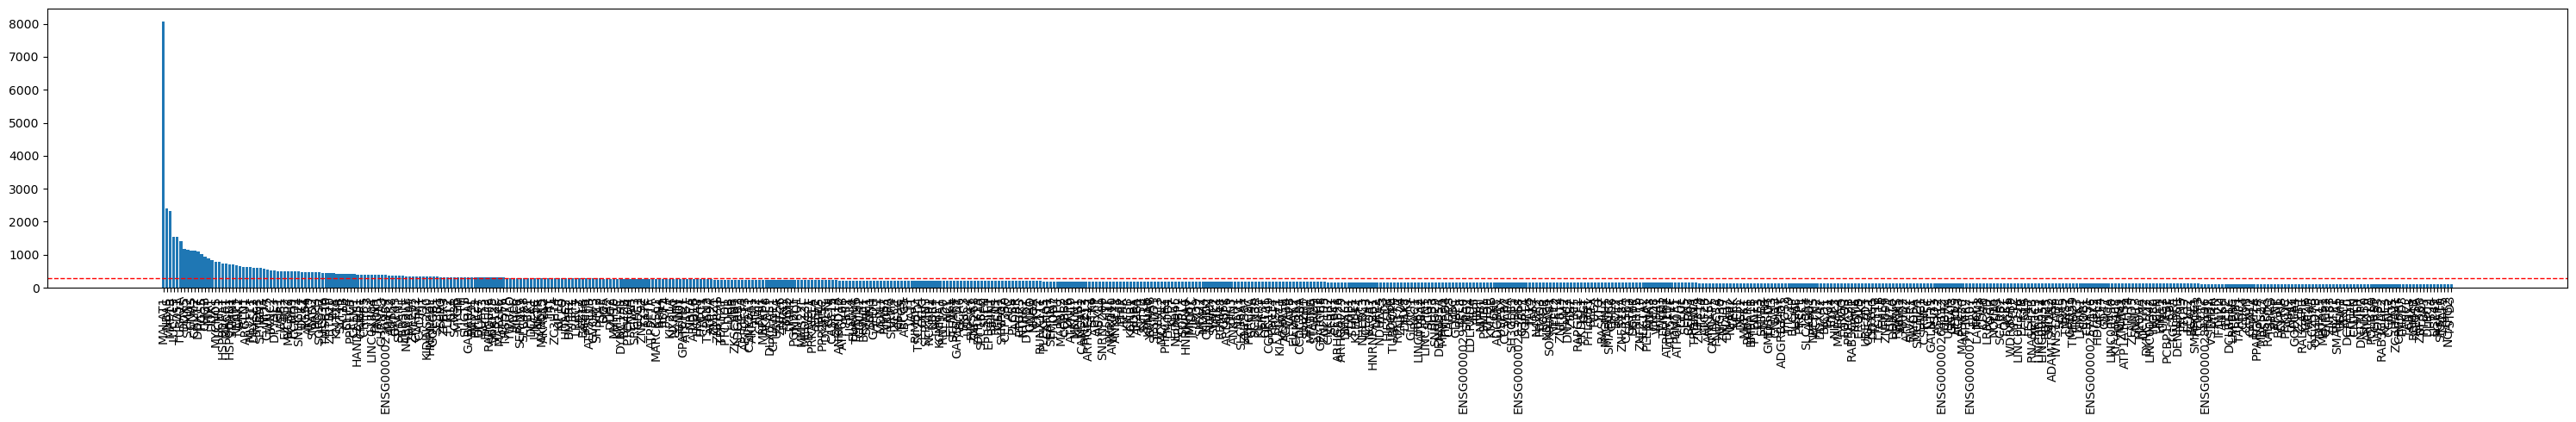

In [33]:
sorted_gex = dict(sorted(sum_gex.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(30, 5))
plt.bar(sorted_gex.keys(), sorted_gex.values())

plt.axhline(y=300, color='red', linestyle='--', linewidth=1)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [40]:
gex_threshold = 300
selected_genes= []
for x in sum_gex:
    if sum_gex[x] > gex_threshold:
        selected_genes.append(x)
print(len(selected_genes))

99


In [41]:
adata = adata[:, adata.var["gene"].isin(selected_genes)]

In [43]:
len(adata.var["gene"].unique().tolist())

99

In [44]:
#gex_threshold = 500
#adata = adata[:,adata.var.sum_gex > gex_threshold]

In [37]:
adata.shape

(2682, 1627)

## Calculate var between leiden

In [21]:
variances = fetch_isoform_varince(adata,
                    group_by="leiden",
                    gene_name_col="gene",
                    transcript_name_col="transcript"
                   )


Processing AnnData object...
Aggregating counts in conditions...
Processing 6018 transcripts in chunks of 1000...
Combining results...
Processed 1000/2252 genes...
Processed 2000/2252 genes...


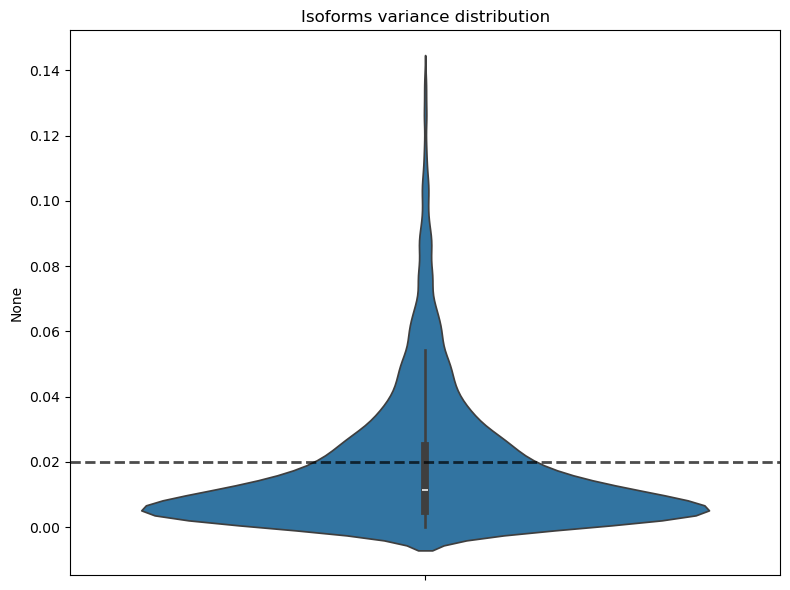

In [22]:
potential_threshold=0.02

plt.figure(figsize=(8, 6))
sns.violinplot(y=variances)
plt.title('Isoforms variance distribution')
# Add horizontal line
plt.axhline(y=potential_threshold, color='black', linestyle='--', linewidth=2, alpha=0.7, label=f'Threshold = {potential_threshold}')
#plt.ylabel('Isoforms')
plt.tight_layout()

plt.show()

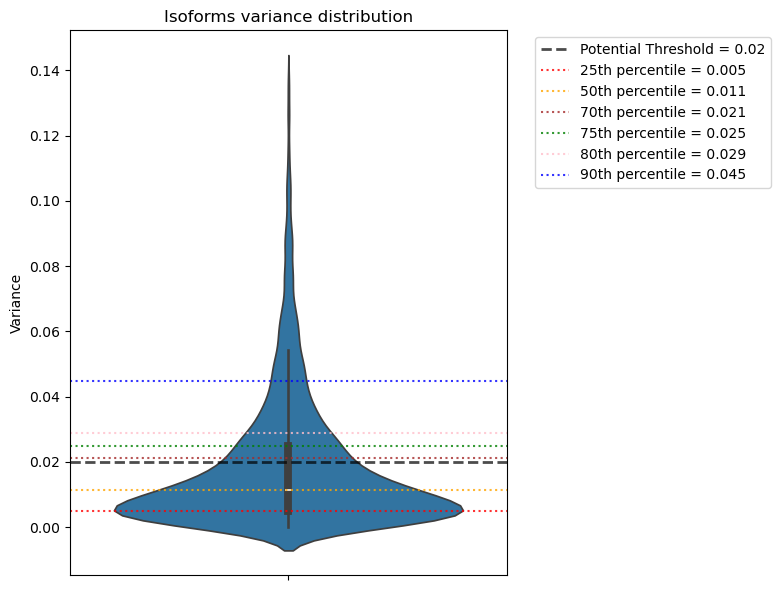

In [23]:
potential_threshold = 0.02

plt.figure(figsize=(8, 6))
sns.violinplot(y=variances)
plt.title('Isoforms variance distribution')

# Add horizontal line for threshold
plt.axhline(y=potential_threshold, color='black', linestyle='--', linewidth=2, alpha=0.7, label=f'Potential Threshold = {potential_threshold}')

# Add percentile lines
p25 = variances.quantile(0.25)
p50 = variances.quantile(0.50)  # median
p70 = variances.quantile(0.70)
p75 = variances.quantile(0.75)
p80 = variances.quantile(0.80)
p90 = variances.quantile(0.90)  # optional 90th percentile

plt.axhline(y=p25, color='red', linestyle=':', linewidth=1.5, alpha=0.8, label=f'25th percentile = {p25:.3f}')
plt.axhline(y=p50, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label=f'50th percentile = {p50:.3f}')
plt.axhline(y=p70, color='brown', linestyle=':', linewidth=1.5, alpha=0.8, label=f'70th percentile = {p70:.3f}')
plt.axhline(y=p75, color='green', linestyle=':', linewidth=1.5, alpha=0.8, label=f'75th percentile = {p75:.3f}')
plt.axhline(y=p80, color='pink', linestyle=':', linewidth=1.5, alpha=0.8, label=f'80th percentile = {p80:.3f}')
plt.axhline(y=p90, color='blue', linestyle=':', linewidth=1.5, alpha=0.8, label=f'90th percentile = {p90:.3f}')
plt.ylabel("Variance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
subset_variances = variances[variances > p80]
isoforms_above_threshold = subset_variances.index.unique().tolist()
genes_above_threshold = adata.var[adata.var.transcript.isin(isoforms_above_threshold)].gene.unique().tolist()

In [25]:
print(f"Number of isoforms above 25th percentile threshold: {len(isoforms_above_threshold)}")
print(f"Number of genes which have at least one isoform above 25th percentile threshold: {len(genes_above_threshold)}")

Number of isoforms above 25th percentile threshold: 1204
Number of genes which have at least one isoform above 25th percentile threshold: 678


In [26]:
subset_adata = adata[:,adata.var[adata.var.gene.isin(genes_above_threshold)].index.tolist()]

In [27]:
subset_adata.var

,gene,transcript,transcript_type,tag,level,transcript_support_level,annot_remark,ERCC,mt,ribo,...,log1p_total_counts,n_cells,m,v,n_obs,res,lp,lpa,qv,highly_variable
ENST00000480479.5,CCNL2,CCNL2-210,retained_intron,Unknown,2.0,2.0,Unknown,False,False,False,...,10.368073,921,-3.447306,-4.829261,921.0,-0.293233,-4.490139e-06,0.000000,0.900586,False
ENST00000482621.5,CCNL2,CCNL2-214,nonsense_mediated_decay,cds_start_NF,2.0,2.0,Unknown,False,False,False,...,9.876717,462,-3.772645,-5.255351,462.0,-0.376958,-2.705523e-05,0.000000,0.909289,False
ENST00000463260.5,CCNL2,CCNL2-205,retained_intron,Unknown,2.0,1.0,Unknown,False,False,False,...,9.622085,681,-3.814621,-5.220773,681.0,-0.297689,-5.316496e-05,0.000000,0.912790,False
ENST00000934645.1,CCNL2,CCNL2-225,protein_coding,TAGENE,2.0,Unknown,['LRGASP'],False,False,False,...,11.038714,320,-3.632191,-4.653152,320.0,0.076611,-1.399196e+00,-0.128326,1.015434,False
ENST00000482365.5,CCNL2,CCNL2-213,retained_intron,Unknown,2.0,2.0,Unknown,False,False,False,...,9.760378,351,-4.098832,-5.434708,351.0,-0.205204,-2.786421e-02,0.000000,0.955931,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000369682.4,PLXNA3,PLXNA3-201,protein_coding,CCDS,2.0,1.0,['MANE_select'],False,False,False,...,9.391001,840,-4.001085,-5.521155,840.0,-0.397836,-4.605824e-09,0.000000,0.872818,False
ENST00000955277.1,PLXNA3,PLXNA3-212,protein_coding,TAGENE,2.0,Unknown,['ENCODE_tissue'],False,False,False,...,10.289768,860,-3.274386,-4.751206,860.0,-0.394697,-4.032422e-09,0.000000,0.872345,False
ENST00000942408.1,USP9Y,USP9Y-217,protein_coding,TAGENE,2.0,Unknown,['ENCODE_tissue'],False,False,False,...,9.488828,463,-4.057862,-5.144414,463.0,0.040475,-1.103503e+00,-0.063511,1.009630,False
ENST00000440408.5,USP9Y,USP9Y-204,protein_coding_CDS_not_defined,Unknown,2.0,1.0,['DKFZp434I143'],False,False,False,...,8.929323,350,-4.347036,-5.548581,350.0,-0.045120,-4.103874e-01,0.000000,0.989858,False


In [29]:
for x in variances.index:
    if "CCNL2" in x:
        print(variances[x],x)
if "CCNL2" in subset_adata.var.gene.unique():
    print("ANK2 is in")

0.036273487 CCNL2-205
0.005760558 CCNL2-210
0.0023306406 CCNL2-213
0.00479572 CCNL2-214
0.0048918664 CCNL2-225
ANK2 is in


In [41]:
adata.var[adata.var["gene"]=="NBAS"]

,gene,transcript,transcript_type,tag,level,transcript_support_level,annot_remark,ERCC,mt,ribo,...,log1p_total_counts,n_cells,m,v,n_obs,res,lp,lpa,qv,highly_variable
ENST00000442506.5,NBAS,NBAS-206,protein_coding,cds_start_NF,2.0,1.0,Unknown,False,False,False,...,10.138652,539,-2.789222,-3.161533,539.0,0.697925,-35.159194,-26.559105,1.196113,True
ENST00000700061.1,NBAS,NBAS-208,protein_coding,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,9.382200,251,-3.406619,-3.752257,251.0,0.741396,-19.536473,-12.488469,1.139449,True
ENST00000700062.1,NBAS,NBAS-209,nonsense_mediated_decay,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,9.076034,261,-3.523656,-3.804112,261.0,0.811679,-23.697002,-16.022991,1.156178,True
ENST00000700065.1,NBAS,NBAS-212,protein_coding_CDS_not_defined,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,10.419991,718,-2.362462,-2.745186,718.0,0.682590,-44.135479,-35.231177,1.223270,True
ENST00000700066.1,NBAS,NBAS-213,protein_coding,GENCODE_Primary,2.0,Unknown,"['CAGE supported TSS', 'RNA-Seq supported only...",False,False,False,...,9.573392,777,-3.161506,-4.332783,777.0,-0.092710,-0.103437,0.000000,0.970057,False
ENST00000700067.1,NBAS,NBAS-214,protein_coding_CDS_not_defined,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,9.633976,897,-3.191831,-4.473672,897.0,-0.202373,-0.001235,0.000000,0.931338,False
ENST00000700068.1,NBAS,NBAS-215,retained_intron,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,11.282083,993,-1.925028,-2.274934,993.0,0.713572,-65.210736,-55.635266,1.278613,True
ENST00000700070.1,NBAS,NBAS-217,nonsense_mediated_decay,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,11.416638,1201,-1.679796,-1.850058,1201.0,0.893012,-119.540396,-109.468490,1.393079,True
ENST00000700071.1,NBAS,NBAS-218,protein_coding_CDS_not_defined,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,10.394056,884,-2.314071,-2.747154,884.0,0.631897,-46.544283,-37.594520,1.230117,True
ENST00000700072.1,NBAS,NBAS-219,retained_intron,RNA_Seq_supported_only,2.0,Unknown,['RNA-Seq supported only'],False,False,False,...,9.726684,781,-2.894356,-3.740246,781.0,0.226238,-7.134283,-3.364337,1.074166,True


In [39]:
for x in variances.index:
    if "NBAS" in x:
        print(variances[x],x)
if "NBAS" in subset_adata.var.gene.unique():
    print("Sox10 is in")

0.0005769468 NBAS-206
0.00021800985 NBAS-208
0.0001972305 NBAS-209
0.0015775164 NBAS-212
0.0005336931 NBAS-213
0.00055041636 NBAS-214
0.0016742456 NBAS-215
0.0014330369 NBAS-217
0.00021098506 NBAS-218
0.00056965137 NBAS-219
0.0006127638 NBAS-220


In [30]:
import scanpy as sc
import matplotlib.pyplot as plt
import math

In [46]:
sc.settings.set_figure_params(
    dpi=150,
    dpi_save=600,
    vector_friendly=True,
    facecolor=None,
    frameon=False)

/tmp/ipykernel_2610590/3058941508.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


In [192]:
import pandas as pd

df = pd.read_csv("/home/matei/data/dui_leiden_filter30.csv")

unique_transcripts = sorted(df["transcript_name"].dropna().unique())

print(len(unique_transcripts))
print(unique_transcripts[1289:])

1300
['ZNF189-203', 'ZNF189-204', 'ZNF280D-203', 'ZNF280D-204', 'ZNF83-201', 'ZNF83-208', 'ZNF83-218', 'ZNF84-208', 'ZNF84-221', 'ZNF84-224', 'ZNF84-226']


/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


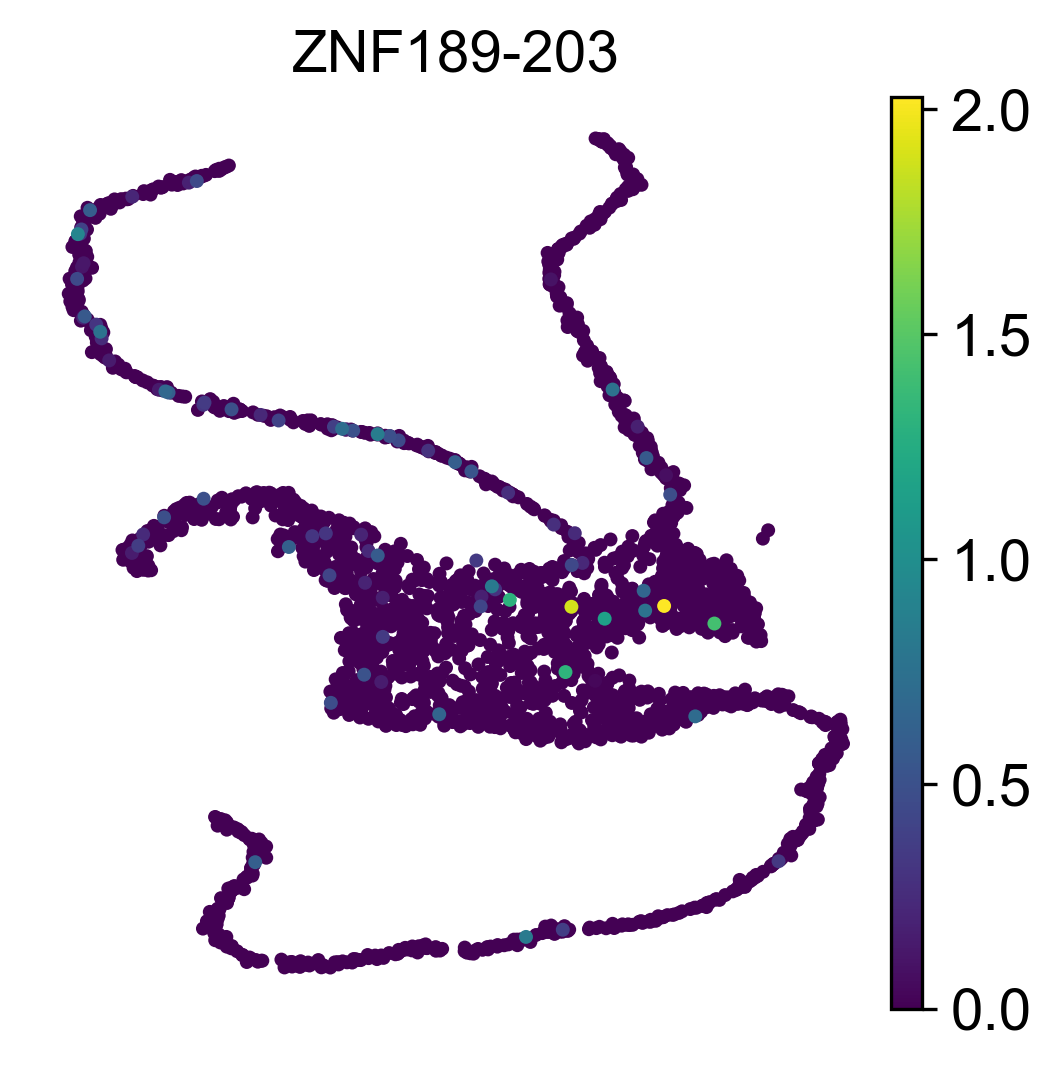

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


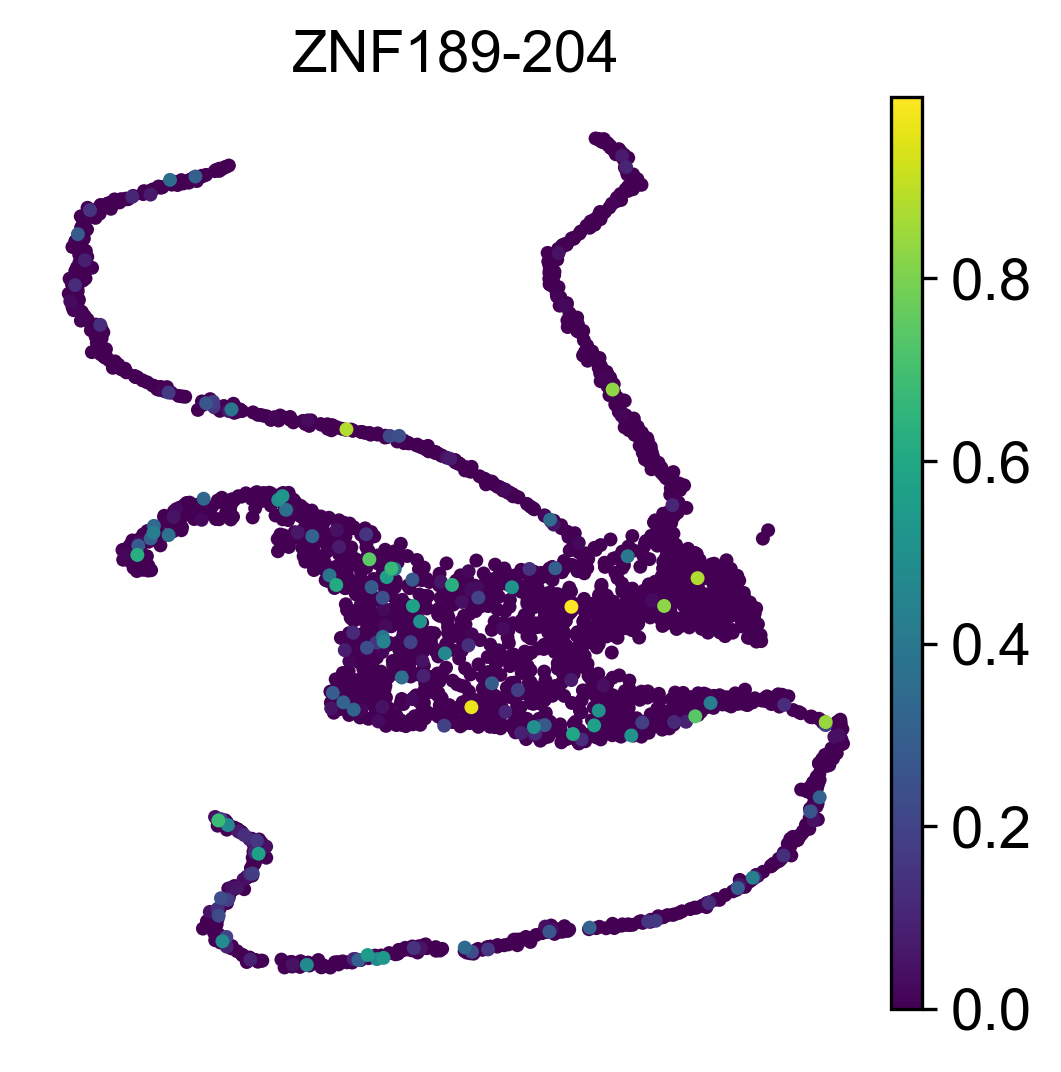

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


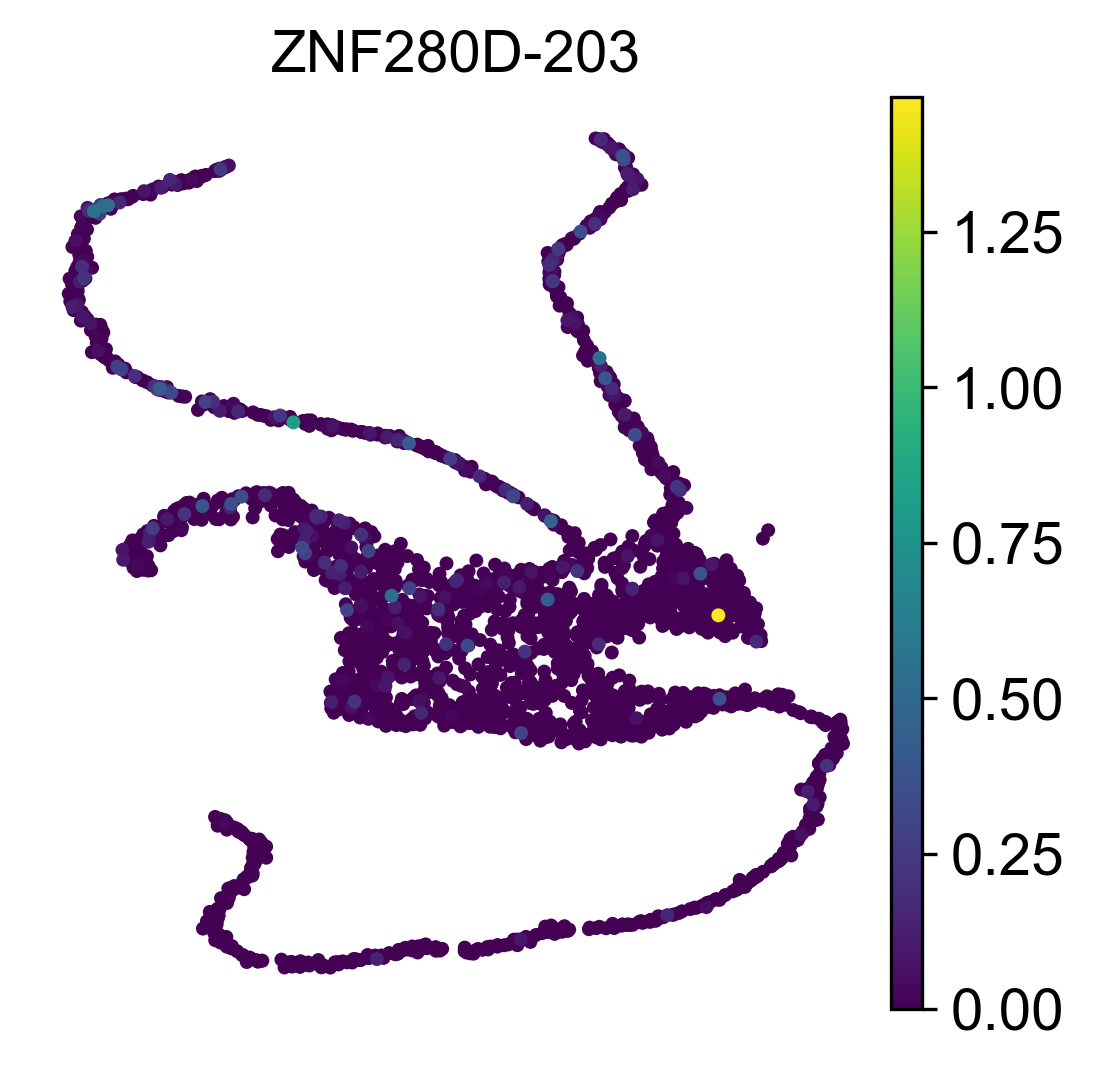

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


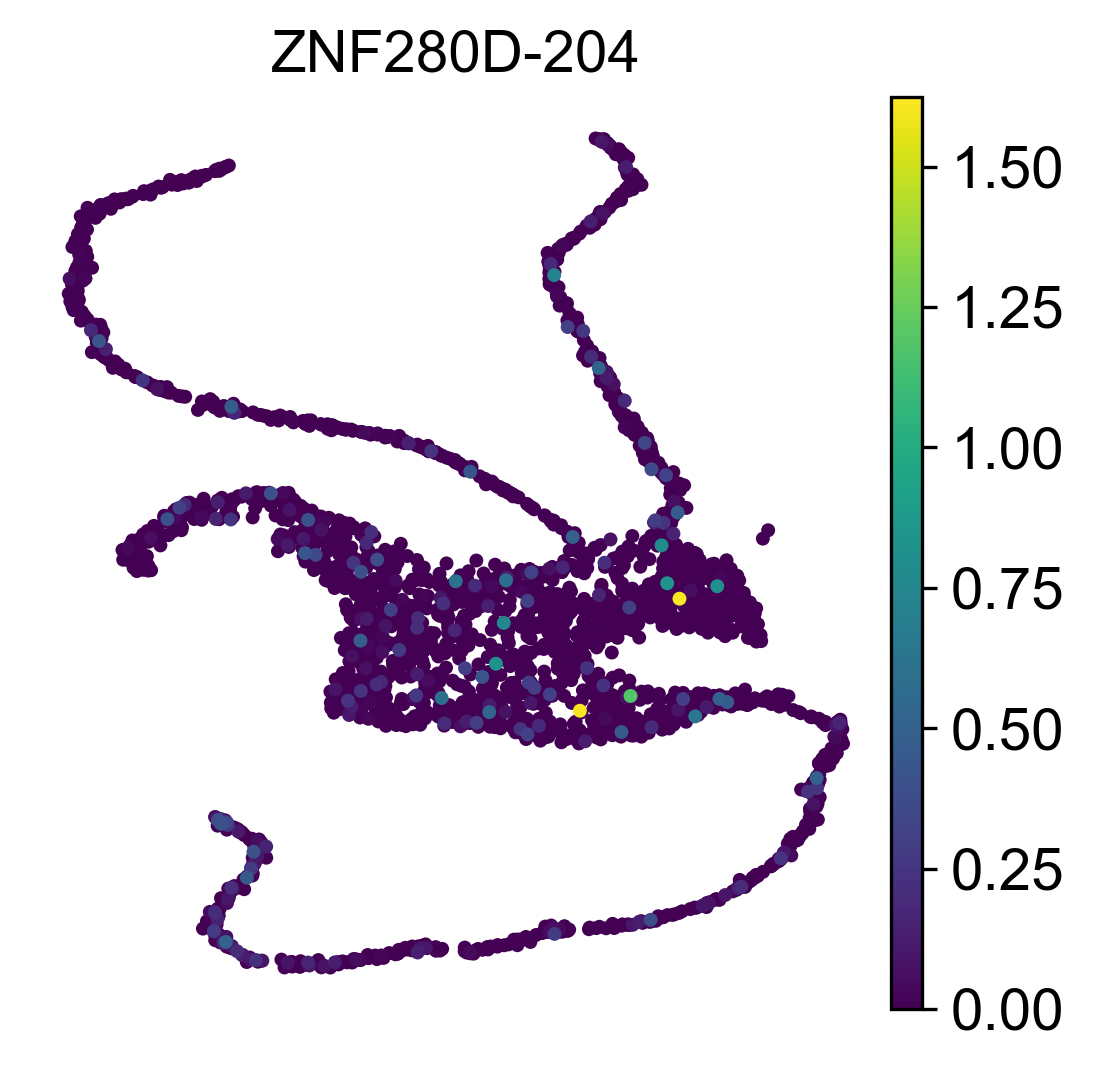

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


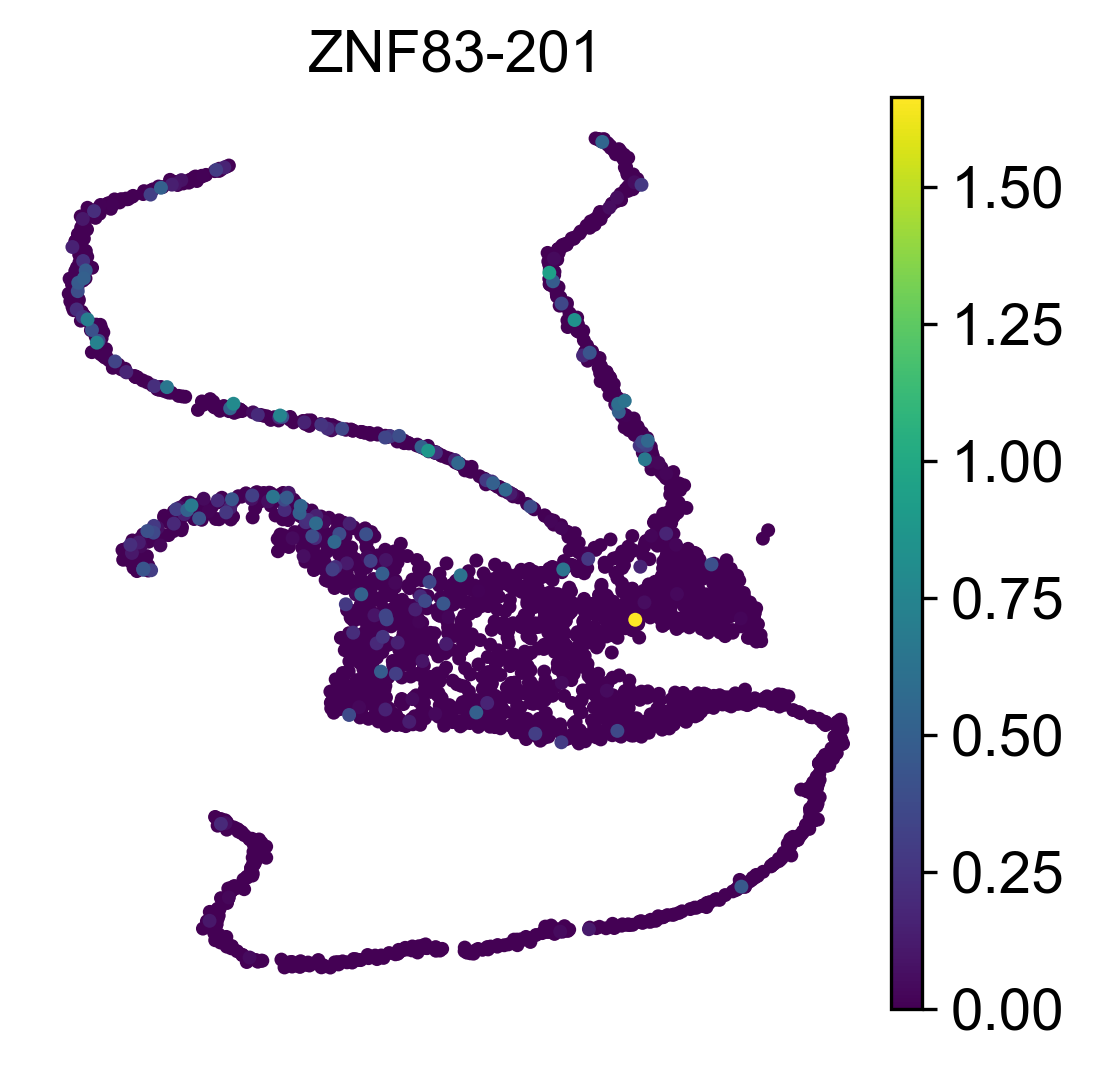

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


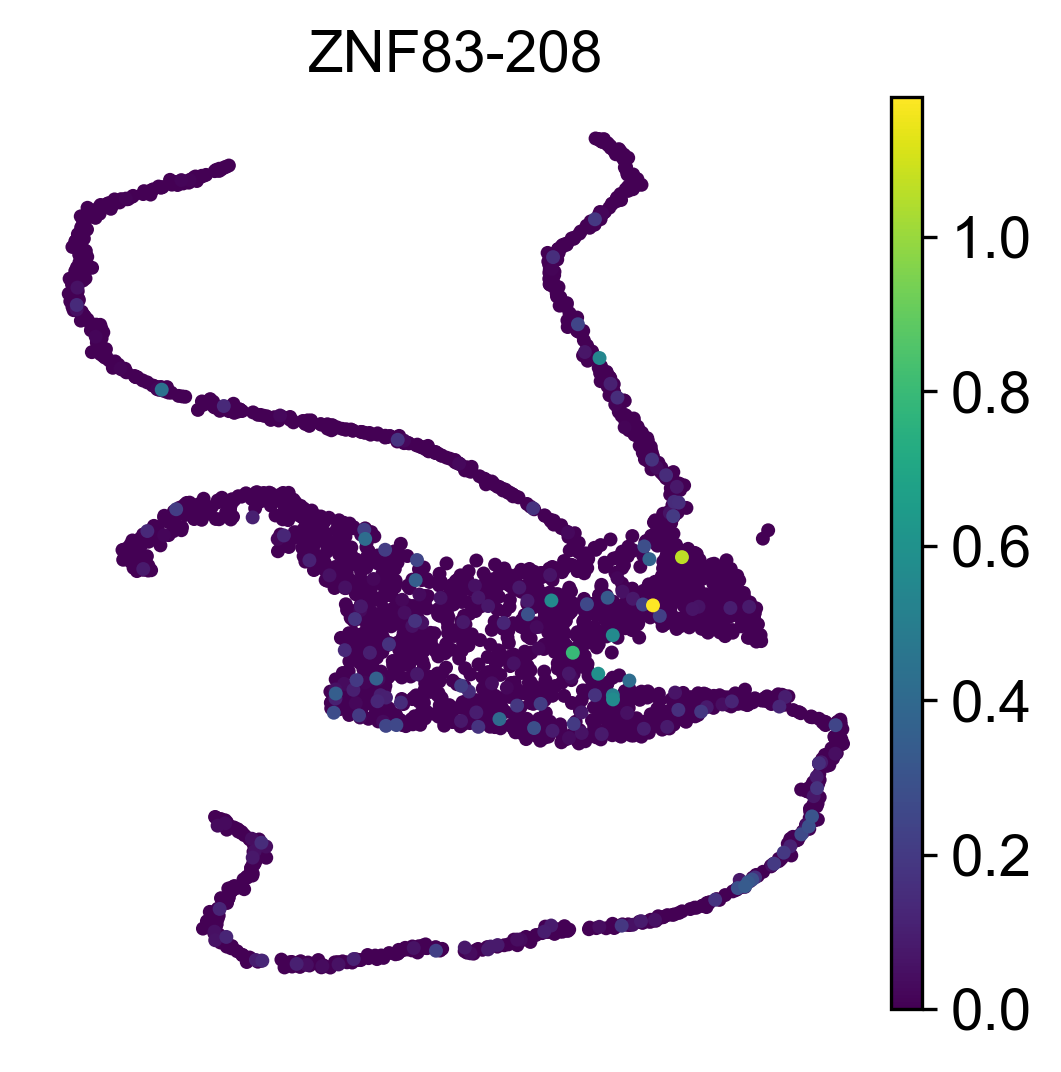

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


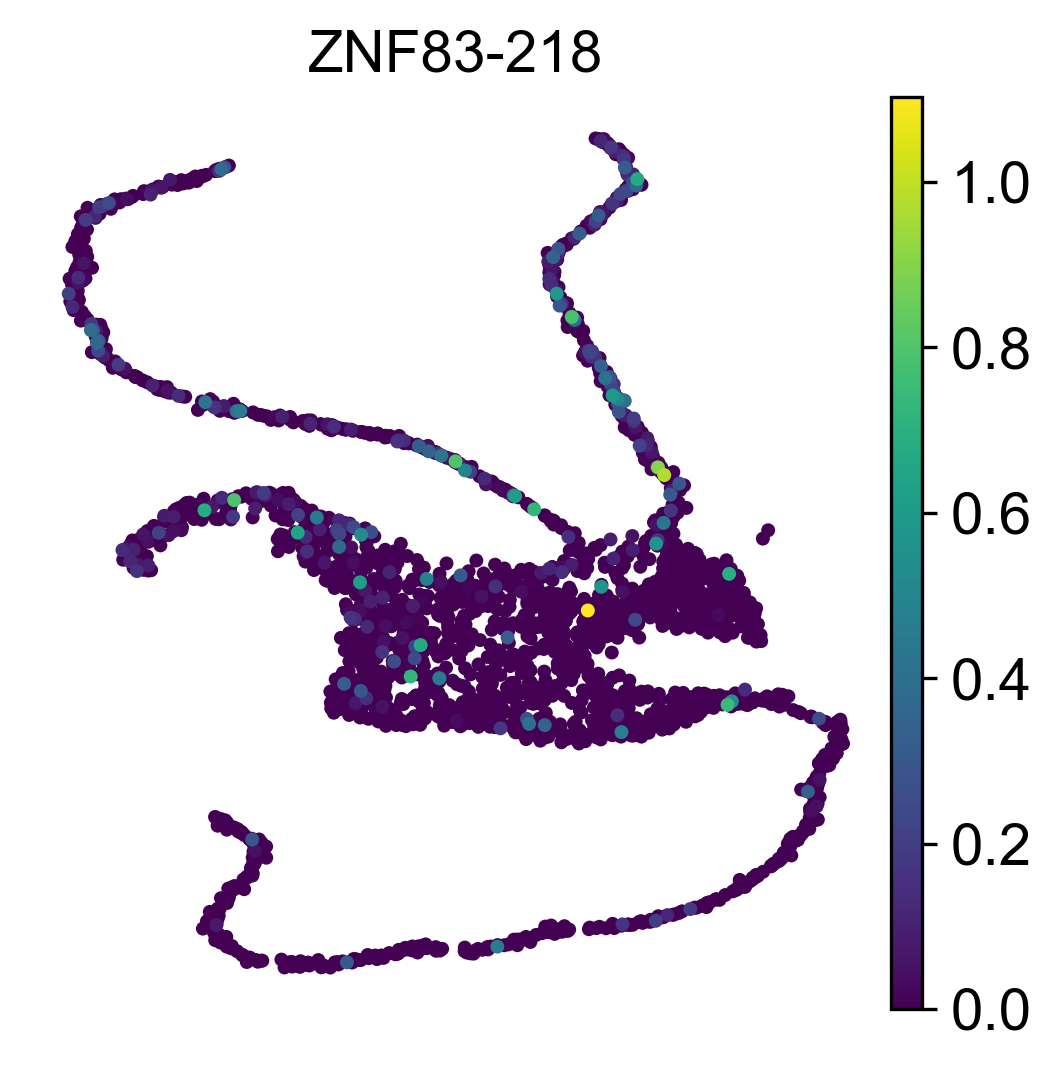

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


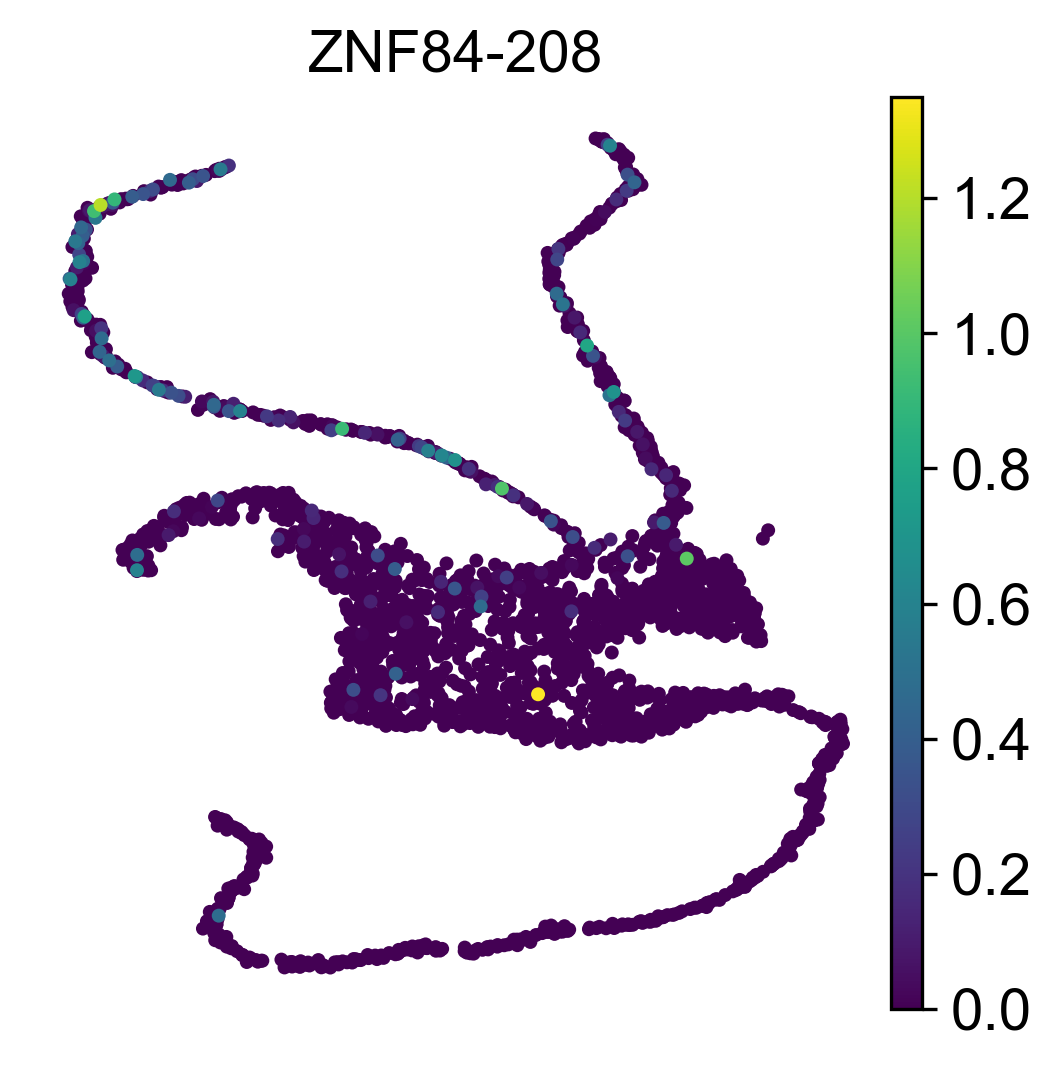

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


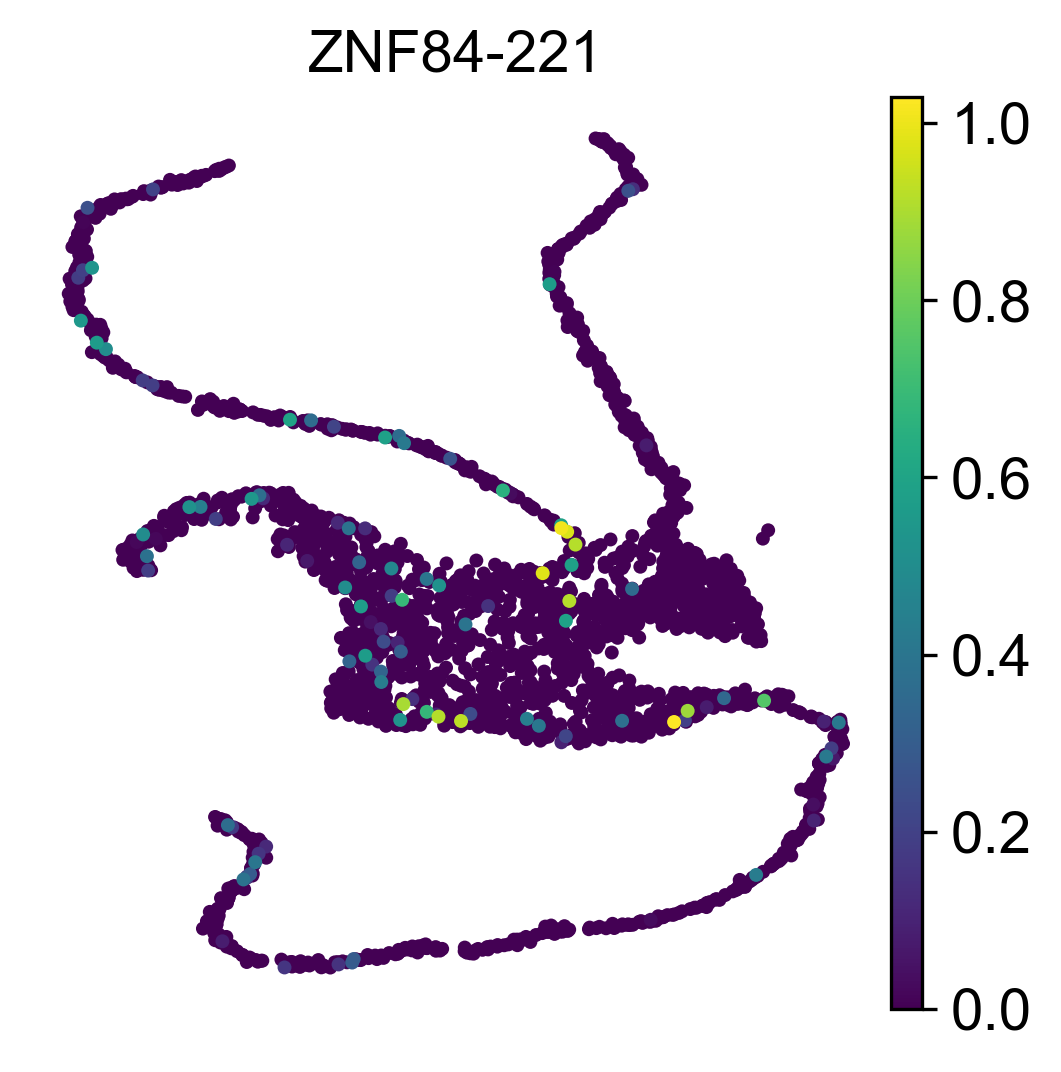

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


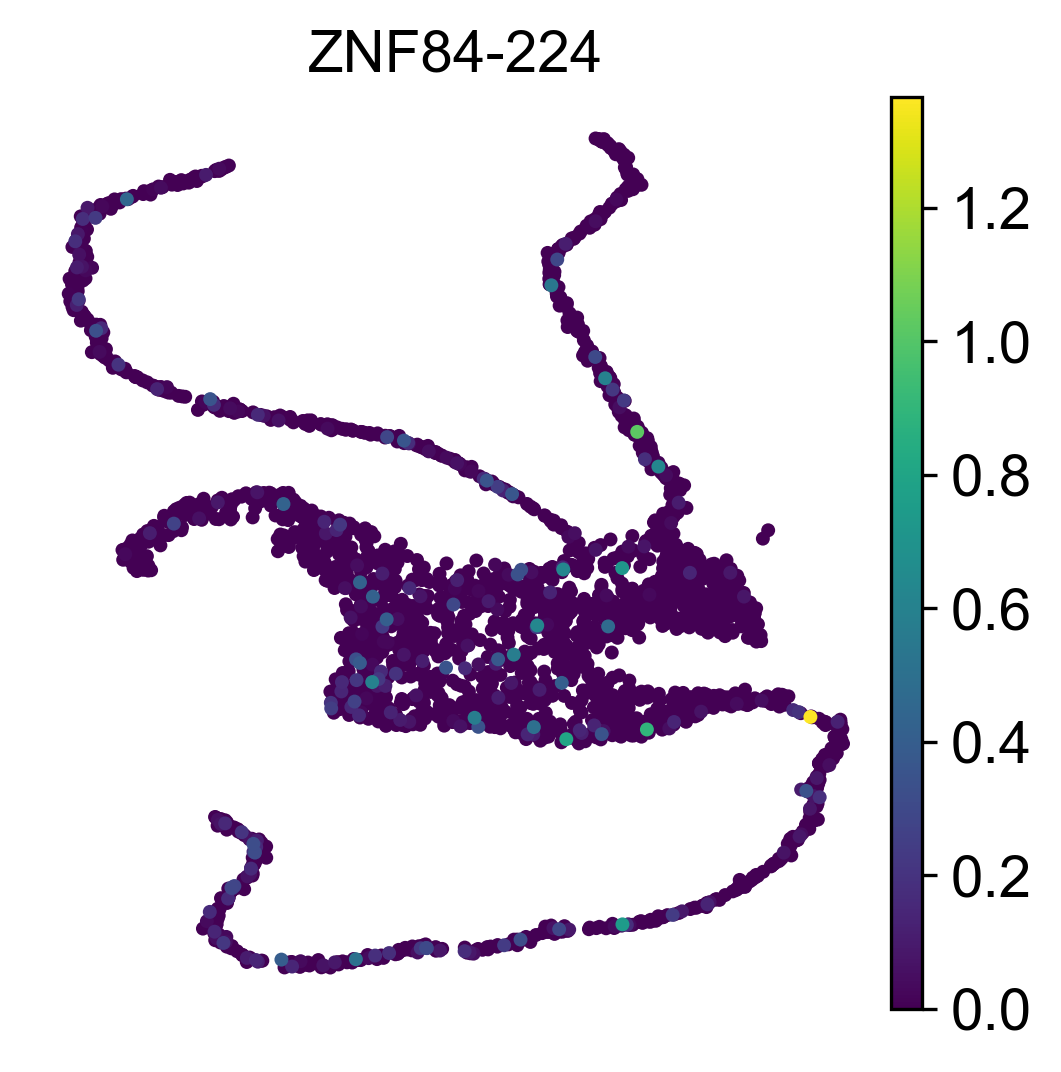

/tmp/ipykernel_2610590/3591888437.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)


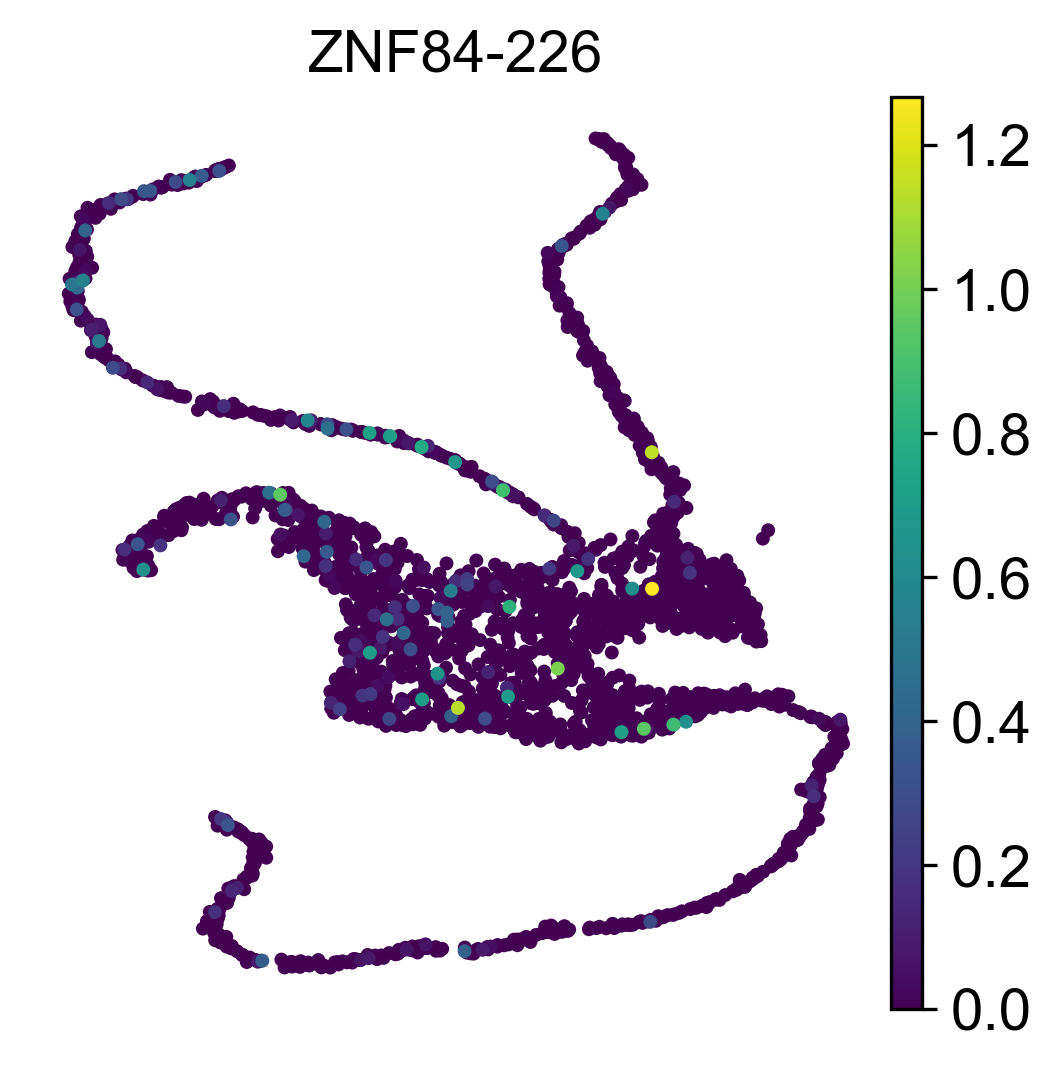

In [193]:
transcripts = ['ZNF189-203', 'ZNF189-204', 'ZNF280D-203', 'ZNF280D-204', 'ZNF83-201', 'ZNF83-208', 'ZNF83-218', 'ZNF84-208', 'ZNF84-221', 'ZNF84-224', 'ZNF84-226']

for tx in transcripts:

    # récupérer les features correspondant au transcript
    feats = adata.var_names[adata.var["transcript"] == tx]

    if len(feats) == 0:
        print(f"{tx} not found")
        continue

    # somme d'expression sur toutes les features associées
    X = adata[:, feats].X

    if hasattr(X, "toarray"):
        X = X.toarray()

    adata.obs[f"sum_exp_{tx}"] = X.sum(axis=1)

    sc.pl.umap(
        adata,
        color=f"sum_exp_{tx}",
        title=tx
    )

In [199]:
sc.pl.umap(adata,color=adata.var[adata.var.gene=="MYCN"].index.tolist())

ValueError: Could not broadcast together arguments with shapes: [0, 1, 1].